# N-body Simulations

# The N-body Problem: Mathematical and Algorithmic Challenges

The **N-body problem** involves predicting the individual motions of a group of celestial objects interacting with each other gravitationally. While the 2-body problem (like Earth and the Moon) has a closed-form analytical solution, the problem becomes chaotic and analytically unsolvable for $N \geq 3$.

### 1. The Mathematical Deadlock
For $N > 2$, there are no general closed-form solutions (integrals of motion) to describe the positions of the bodies over time. This necessitates the use of **numerical integration** to approximate the state of the system at discrete time steps.

### 2. Computational Complexity: The $O(N^2)$ Barrier
The primary algorithmic challenge is the calculation of gravitational forces. According to Newton's Law of Universal Gravitation:
$$F_{ij} = G \frac{m_i m_j}{r_{ij}^2}$$

In a system of $N$ particles, each particle interacts with every other particle. 
- For $N=100$, we perform $\approx 10,000$ calculations per step.
- For $N=1,000,000$ (a small galaxy), we would need $1,000,000,000,000$ calculations per step.

This **$O(N^2)$ complexity** makes direct summation impossible for large-scale simulations, requiring more advanced algorithms like **Barnes-Hut** or **Fast Multipole Methods**.

### 3. Numerical Challenges
- **Singularities:** When two particles get extremely close, the distance $r \to 0$, causing the force to approach infinity. This leads to massive numerical errors. We mitigate this using **softening parameters**.
- **Energy Drift:** Simple integration methods (like Euler) fail to conserve energy, causing orbits to artificially spiral outward or inward. This requires **Symplectic Integrators** like Velocity Verlet.
- **Sensitivity to Initial Conditions:** The system is inherently chaotic. Tiny differences in initial positions lead to vastly different outcomes over time (the "Butterfly Effect").

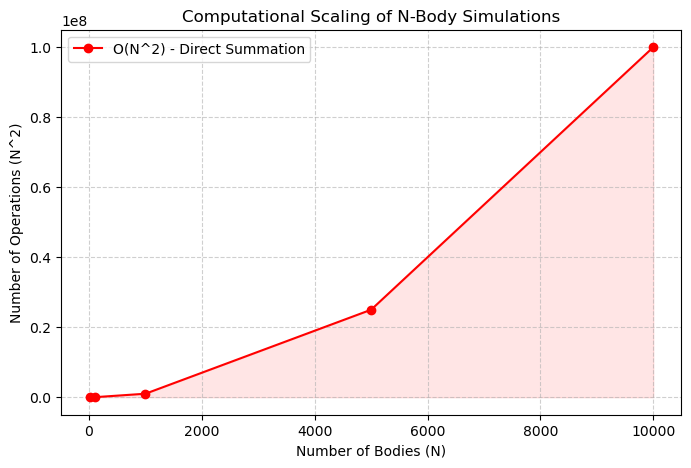

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Visualizing the O(N^2) complexity growth
n_values = np.array([10, 100, 1000, 5000, 10000])
complexity_n2 = n_values**2

plt.figure(figsize=(8, 5))
plt.plot(n_values, complexity_n2, 'r-o', label='O(N^2) - Direct Summation')
plt.fill_between(n_values, complexity_n2, color='red', alpha=0.1)
plt.title("Computational Scaling of N-Body Simulations")
plt.xlabel("Number of Bodies (N)")
plt.ylabel("Number of Operations (N^2)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()